In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import scipy 
from ipywidgets import widgets
from IPython.display import display
import yaml

In [2]:
pd.set_option('display.max_rows', None)

# Show every column in the DataFrame
pd.set_option('display.max_columns', None)

# Show the full content within each cell (preventing long text from being cut off)
pd.set_option('display.max_colwidth', None)

# Show all items in a list inside a cell
pd.set_option('display.max_seq_items', None)


In [3]:
with open('../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

In [32]:
df = pd.read_parquet(config['data_source']['file_paths']['cleaned_dataset'])


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74779 entries, 0 to 74778
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        74777 non-null  string        
 1   city                         74779 non-null  string        
 2   district                     74779 non-null  string        
 3   area                         68237 non-null  string        
 4   neighborhood                 39763 non-null  string        
 5   property_type                74779 non-null  string        
 6   sale_or_rent                 74779 non-null  string        
 7   price                        74779 non-null  Int64         
 8   seller_name                  74779 non-null  string        
 9   property_subtype             74779 non-null  string        
 10  bedrooms                     74779 non-null  Int64         
 11  bathrooms                    74779 non-nu

In [7]:
## Since this is the start of feature engineering this dataset well be split across 4 categories 
## apartemen_sale, apartement_rent, villas_sale and villas_rent
dfs = {}
for type in df['property_type'].unique():
    for transaction in df['sale_or_rent'].unique():
        resulted_df = df[ (df['property_type'] == type)  & (df['sale_or_rent'] == transaction)]
        key = type+"_"+transaction
        dfs[key] = resulted_df 


In [8]:
# First there are some repetitive process that will be done across 4 dataframes 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74779 entries, 0 to 74778
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        74777 non-null  string        
 1   city                         74779 non-null  string        
 2   district                     74779 non-null  string        
 3   area                         68237 non-null  string        
 4   neighborhood                 39763 non-null  string        
 5   property_type                74779 non-null  string        
 6   sale_or_rent                 74779 non-null  string        
 7   price                        74779 non-null  Int64         
 8   seller_name                  74779 non-null  string        
 9   property_subtype             74779 non-null  string        
 10  bedrooms                     74779 non-null  Int64         
 11  bathrooms                    74779 non-nu

In [9]:
# columns like purpose, payment option and seller_name must be investigated to see if it drive real value
for colum in ['purpose', 'payment option', 'seller_name']:
    print(f"The number of unique values in {colum} is  = {df[colum].nunique()}")
    if df[colum].nunique() <= 10:
        print(f"{colum} uniques values are {df[colum].unique()}")
        print(f"{colum} sum of null values are {df[colum].isna().sum()}")

The number of unique values in purpose is  = 2
purpose uniques values are <StringArray>
['for sale', 'for rent']
Length: 2, dtype: string
purpose sum of null values are 0
The number of unique values in payment option is  = 3
payment option uniques values are <StringArray>
['cash', 'installment', 'cash or installment', <NA>]
Length: 4, dtype: string
payment option sum of null values are 16865
The number of unique values in seller_name is  = 1632


In [33]:
# The first desicsion that I will not need both purpose and seller_name in my model 
# 1. Purpose is the same as rent_or_sale 
# 2. seller_name won't be available at inference and even if it was available it will not provide useful general information

df.drop(columns=['purpose', 'seller_name', 'price_tier', 'city'], inplace=True)

In [38]:
## Therefroe we need to check wither payment plan will affect the price or not
filtered_df = df.groupby('payment option')['price'].agg(
    ['count', 'mean','median','std']
).reset_index().sort_values(by = 'count', ascending= False)
filtered_df.head()

,payment option,count,mean,median,std
0,cash,34600,16672279.824971,10000000.0,23169966.388508
1,cash or installment,12961,13510405.029859,9970000.0,11702746.876841
2,installment,10353,15274467.49831,11000000.0,13406035.532626


In [32]:
import seaborn as sns

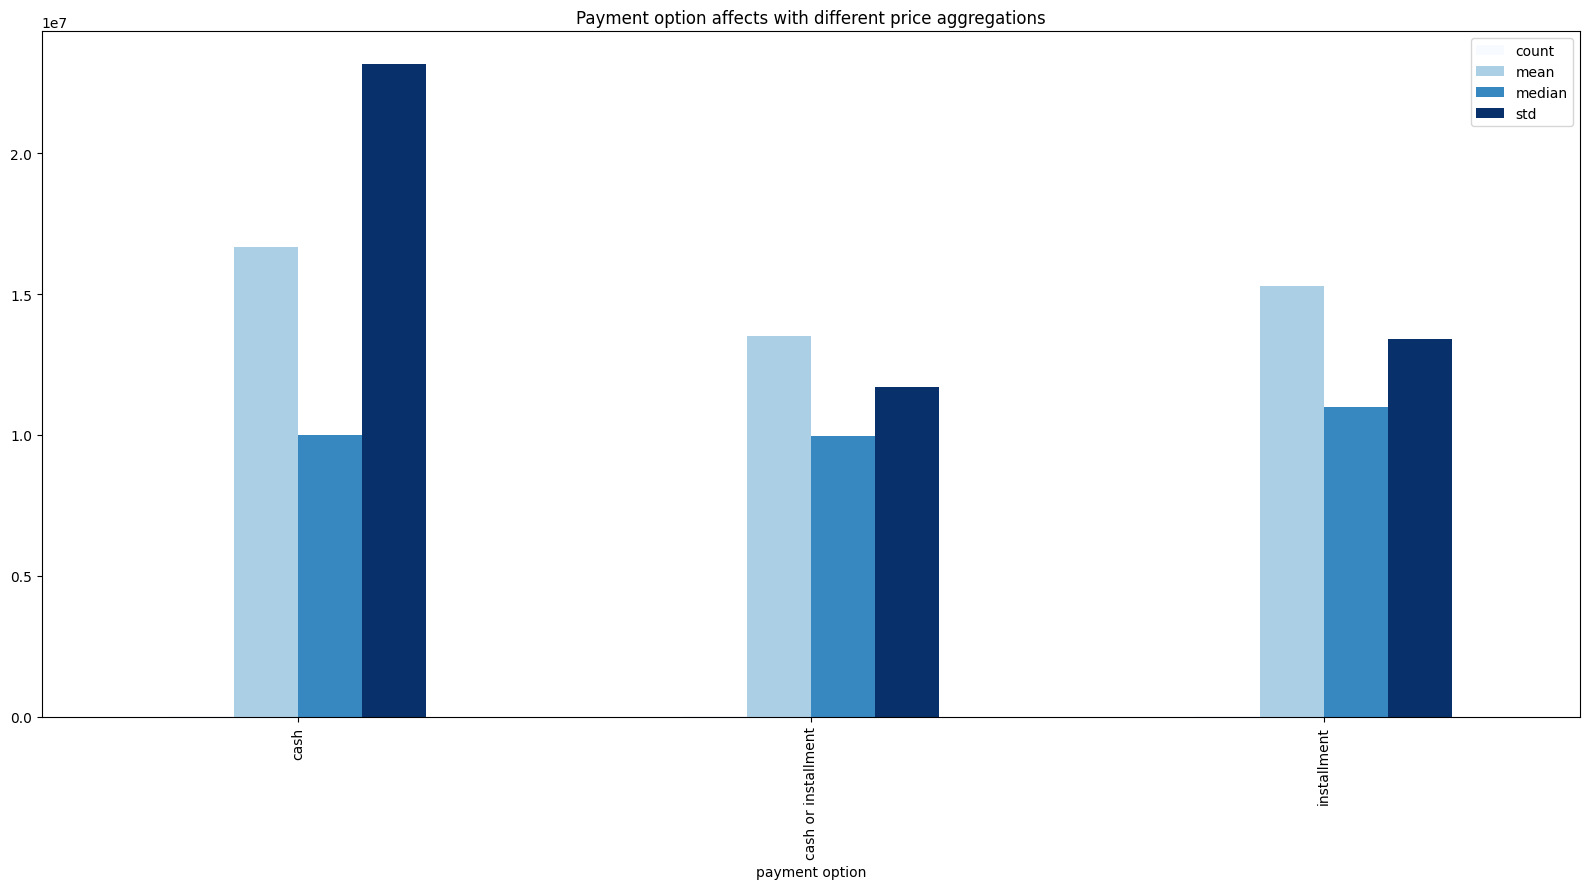

In [43]:
filtered_df.set_index('payment option')[['count', 'mean','median','std']].plot(
    kind = 'bar',
    figsize= (16,9),
     colormap='Blues'
)
plt.title('Payment option affects with different price aggregations')
plt.tight_layout()
plt.show()

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74779 entries, 0 to 74778
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        74777 non-null  string        
 1   city                         74779 non-null  string        
 2   district                     74779 non-null  string        
 3   area                         68237 non-null  string        
 4   neighborhood                 39763 non-null  string        
 5   property_type                74779 non-null  string        
 6   sale_or_rent                 74779 non-null  string        
 7   price                        74779 non-null  Int64         
 8   property_subtype             74779 non-null  string        
 9   bedrooms                     74779 non-null  Int64         
 10  bathrooms                    74779 non-null  Int64         
 11  ownership                    47148 non-nu

water meter
1    44131
0    30648
Name: count, dtype: int64

In [34]:
## Most of our columns are either strings or bool so let's create a function that changes the every bool column 
## Into 0 or 1 better than one-hot-encoding 
def engineer_bool_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    bool_cols = df.select_dtypes(include='bool').columns.tolist()
    

    df[bool_cols] = df[bool_cols].astype('int')
    return df
bool_cleaned_df = engineer_bool_columns(df)
bool_cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74779 entries, 0 to 74778
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        74777 non-null  string        
 1   district                     74779 non-null  string        
 2   area                         68237 non-null  string        
 3   neighborhood                 39763 non-null  string        
 4   property_type                74779 non-null  string        
 5   sale_or_rent                 74779 non-null  string        
 6   price                        74779 non-null  Int64         
 7   property_subtype             74779 non-null  string        
 8   bedrooms                     74779 non-null  Int64         
 9   bathrooms                    74779 non-null  Int64         
 10  ownership                    47148 non-null  string        
 11  payment option               57914 non-nu

In [35]:
# Now the string columns 
string_cols = df.select_dtypes(include='string').columns.tolist()
for col in string_cols:
    if col == 'title':
        continue
    print(f'{col} have {df[col].nunique()} values with {df[col].isnull().sum()} null values')

district have 39 values with 0 null values
area have 293 values with 6542 null values
neighborhood have 116 values with 35016 null values
property_type have 2 values with 0 null values
sale_or_rent have 2 values with 0 null values
property_subtype have 11 values with 0 null values
ownership have 2 values with 27631 null values
payment option have 3 values with 16865 null values
furnished have 2 values with 12656 null values
completion status have 2 values with 16807 null values
delivery term have 6 values with 54353 null values
rental frequency have 4 values with 57972 null values
level_clean have 20 values with 41097 null values


In [13]:
df['delivery term'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 74779 entries, 0 to 74778
Series name: delivery term
Non-Null Count  Dtype 
--------------  ----- 
20426 non-null  string
dtypes: string(1)
memory usage: 584.3 KB


In [14]:
df[df['sale_or_rent'] == 'sale']['delivery term'].info()

<class 'pandas.core.series.Series'>
Index: 57972 entries, 0 to 74425
Series name: delivery term
Non-Null Count  Dtype 
--------------  ----- 
19489 non-null  string
dtypes: string(1)
memory usage: 905.8 KB


In [26]:
df['delivery term'] = df['delivery term'].replace('not_finished', 'not finished')

In [17]:
df['delivery term'].unique()

<StringArray>
[           <NA>,      'finished', 'semi finished',  'core & shell',
 'semi_finished',  'not finished']
Length: 6, dtype: string

In [36]:
# As it very important feature and it's so informative I will make all the null values in it as Unkown and will be treated as it's own categore
bool_cleaned_df['delivery term'] = bool_cleaned_df['delivery term'].replace('not_finished', 'not finished')
bool_cleaned_df['delivery term'] = bool_cleaned_df['delivery term'].replace('semi_finished', 'semi finished')
bool_cleaned_df['delivery term'] = bool_cleaned_df['delivery term'].fillna('Unkown')
bool_cleaned_df['delivery term'].value_counts()

delivery term
Unkown           54353
finished         16280
semi finished     2438
not finished       880
core & shell       828
Name: count, dtype: Int64

In [41]:
string_cols = bool_cleaned_df.select_dtypes(include='string').columns.tolist()
one_hot_columns =  []
for col in string_cols:
    if bool_cleaned_df[col].nunique() < 40:
        one_hot_columns.append(col)
encoded_df = pd.get_dummies(bool_cleaned_df, columns=one_hot_columns)
encoded_df = engineer_bool_columns(encoded_df)

encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74779 entries, 0 to 74778
Columns: 116 entries, title to level_clean_upper floor
dtypes: Int64(5), datetime64[ns](1), float64(1), int64(106), string(3)
memory usage: 66.5 MB


In [42]:
strings_cols = encoded_df.select_dtypes(include='string').columns.tolist()

In [43]:
for col in strings_cols:
    print(f"{col} have {encoded_df[col].nunique()} unique values")

title have 66547 unique values
area have 293 unique values
neighborhood have 116 unique values


In [ ]:
# Next step deal with high cardinality features